In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os
from langchain_groq import ChatGroq
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint

In [2]:

pip install langchain-groq

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
load_dotenv()

True

In [5]:
model = ChatGroq(
    model_name="qwen/qwen3.8-27b"
)


In [ ]:
# model= ChatHuggingFace(llm=llm)

In [6]:
print(model.invoke('hi how are you'))

content="Hi! I'm doing well, thank you for asking. How are you doing today? Is there anything specific I can help you with?" additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 16, 'total_tokens': 45, 'completion_time': 0.054993213, 'completion_tokens_details': None, 'prompt_time': 0.000853363, 'prompt_tokens_details': None, 'queue_time': 0.044052176, 'total_time': 0.055846576}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_43b3b61db6', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--01a12201-8bb3-7633-a5e6-4b4ff6604686-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 16, 'output_tokens': 29, 'total_tokens': 45}


In [7]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [8]:

class QnAState(TypedDict):
      qus:str
      ans:str

In [9]:
def Generate(state: QnAState)-> QnAState:

    qus=state['qus']
    ans=" "

    ans= model.invoke(qus).content
    
    state['ans']=ans

    return state
    


In [10]:
graph= StateGraph(QnAState)

graph.add_node('Generate', Generate)

graph.add_edge(START, 'Generate')
graph.add_edge('Generate', END)


workflow= graph.compile()



In [11]:
initial_state={'qus':'what is the capital of India and give me the best 10 places to visit there', 'ans':''}

final_state= workflow.invoke(initial_state)

print(final_state)

{'qus': 'what is the capital of India and give me the best 10 places to visit there', 'ans': 'The capital of India is **New Delhi**.\n\nWhile New Delhi is the official capital territory, it is often visited in conjunction with **Old Delhi** (the historic heart of the city) and the broader **National Capital Territory (NCT)** of Delhi. Here are the **10 best places to visit** in and around New Delhi, blending history, architecture, culture, and modernity:\n\n### 1. **Qutub Minar**\n   - **Why go:** A UNESCO World Heritage Site and one of the tallest minarets in the world (73 meters). Built in the 12th century, it’s a striking example of Indo-Islamic architecture.\n   - **Tip:** Visit early morning to avoid crowds and heat.\n\n### 2. **Red Fort (Lal Qila)**\n   - **Why go:** The historic Mughal-era fort built by Shah Jahan in 1639. It symbolizes India’s independence (PM’s speech on Independence Day is delivered from here).\n   - **Tip:** Combine with a visit to Chandni Chowk nearby for s

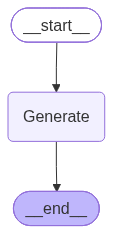

In [12]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())